# 06 – Modelos no supervisados (clustering) para riesgo de hipertensión

Objetivo:
1. Usar el dataset `nhanes_model_input_scaled.csv` (features ya estandarizadas) para aplicar modelos de clustering.
2. Explorar distintos valores de *k* para KMeans y evaluar:
   - Inercia (SSE).
   - Silhouette score.
3. Seleccionar un *k* razonable y:
   - Entrenar un modelo final.
   - Describir los clusters (tamaño, perfil de variables).
   - Ver cómo se distribuye la etiqueta `HTN_label` en cada cluster (solo para interpretación, no para entrenar).

Este notebook es exploratorio; la versión productiva se implementa en el pipeline `unsupervised_models` de Kedro.


In [5]:
import os
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

plt.style.use("default")

# Asegurar que estamos en la raíz del proyecto (no en /notebooks)
cwd = os.getcwd()
if cwd.endswith("notebooks"):
    os.chdir("..")
    print("Cambiando directorio de trabajo a la raíz del proyecto.")
print("Working dir:", os.getcwd())

df_scaled = pd.read_csv("data/05_model_input/nhanes_model_input_scaled.csv")

print(df_scaled.shape)
df_scaled.head()


Working dir: c:\Users\Ella es ella\Documents\kedro_projects\nhanes-htn
(11268, 34)


,id,gender_code,age_years,race_ethnicity_code,education_level_code,income_poverty_ratio,weight_kg,height_cm,bmi,waist_cm,...,vigorous_recreation_days,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_days,moderate_recreation_minutes,sedentary_minutes,cycle,SBP_mean,DBP_mean,HTN_label
0,83732,1,0.704896,3,5,1.307607,0.582950,1.824479,-0.237956,0.080069,...,-0.508399,-0.448176,1,2.228154,0.093001,0.643800,2015_2016,122.666667,65.333333,0
1,83733,1,0.219927,3,3,-0.720051,0.384928,0.515166,0.177939,0.492555,...,-0.508399,-0.448176,2,-0.686614,-0.535054,-0.258061,2015_2016,140.000000,86.000000,1
2,83734,1,1.567064,3,3,-0.594561,0.069894,0.385234,-0.099325,1.014228,...,-0.508399,-0.448176,2,-0.686614,-0.535054,0.643800,2015_2016,135.333333,45.333333,0
3,83735,2,0.381584,3,5,1.710497,1.258025,-0.534283,1.786068,0.626006,...,-0.508399,-0.448176,2,-0.686614,-0.535054,0.643800,2015_2016,134.000000,70.000000,0
4,83736,2,-0.372813,4,4,-0.779494,-1.199247,-0.134493,-1.277695,-1.175587,...,-0.508399,-0.448176,2,-0.686614,-0.535054,0.944420,2015_2016,104.000000,60.000000,0


In [6]:
# Distribución de la etiqueta, si existe
if "HTN_label" in df_scaled.columns:
    print("Distribución HTN_label:")
    print(df_scaled["HTN_label"].value_counts(dropna=False))
else:
    print("No se encontró columna HTN_label. Solo se hará clustering sin evaluación respecto a la etiqueta.")

# Seleccionar features numéricas para clustering (excluyendo HTN_label)
feature_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

if "HTN_label" in feature_cols:
    feature_cols.remove("HTN_label")

X = df_scaled[feature_cols].values

print(f"Número de features usadas para clustering: {len(feature_cols)}")


Distribución HTN_label:
HTN_label
0    8967
1    2301
Name: count, dtype: int64
Número de features usadas para clustering: 32


In [8]:
from sklearn.impute import SimpleImputer

def evaluate_kmeans_for_k_range(X, k_values, random_state=42, impute_strategy="mean"):
    """
    Para cada k en k_values entrena KMeans y devuelve un DataFrame
    con inercia y silhouette score.

    Se aplica imputación a X para manejar NaNs antes de ajustar KMeans.
    """
    # Imputar valores faltantes (no modifica X original)
    imputer = SimpleImputer(strategy=impute_strategy)
    X_imputed = imputer.fit_transform(X)

    results = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(X_imputed)

        inertia = km.inertia_
        try:
            sil = silhouette_score(X_imputed, labels)
        except Exception:
            sil = np.nan

        results.append(
            {
                "k": k,
                "inertia": inertia,
                "silhouette": sil,
            }
        )

    return pd.DataFrame(results)


k_values = [2, 3, 4, 5, 6]
results_k = evaluate_kmeans_for_k_range(X, k_values)
results_k


,k,inertia,silhouette
0,2,8.702997e+10,0.625912
1,3,3.865479e+10,0.589246
2,4,2.161074e+10,0.573249
3,5,1.385283e+10,0.561245
4,6,9.669133e+09,0.552193


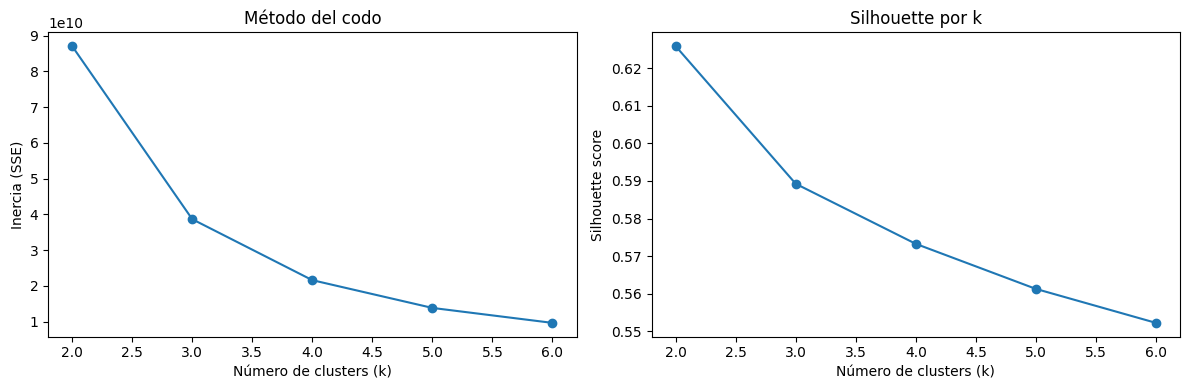

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de codo (inercia)
ax[0].plot(results_k["k"], results_k["inertia"], marker="o")
ax[0].set_xlabel("Número de clusters (k)")
ax[0].set_ylabel("Inercia (SSE)")
ax[0].set_title("Método del codo")

# Silhouette
ax[1].plot(results_k["k"], results_k["silhouette"], marker="o")
ax[1].set_xlabel("Número de clusters (k)")
ax[1].set_ylabel("Silhouette score")
ax[1].set_title("Silhouette por k")

plt.tight_layout()
plt.show()


## Elección del número de clusters

En base a los gráficos anteriores:

- El “codo” de la inercia se observa aproximadamente en `k = 3`–`4` (ajustar según los resultados reales).
- El `silhouette_score` suele ser máximo en un rango similar.

Para este proyecto (EV3), escogeremos un valor de referencia, por ejemplo `k = 3`, que equilibra:
- Interpretabilidad clínica (3 grupos de riesgo).
- Calidad geométrica de los clusters (silhouette razonable).


In [11]:
k_final = 3  # ajusta si tus gráficos sugieran otro valor

# Imputar NaNs antes de ajustar KMeans (SimpleImputer ya fue importado en una celda anterior)
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(X_imputed)

df_clusters = df_scaled.copy()
df_clusters["cluster"] = cluster_labels

df_clusters.head()


,id,gender_code,age_years,race_ethnicity_code,education_level_code,income_poverty_ratio,weight_kg,height_cm,bmi,waist_cm,...,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_days,moderate_recreation_minutes,sedentary_minutes,cycle,SBP_mean,DBP_mean,HTN_label,cluster
0,83732,1,0.704896,3,5,1.307607,0.582950,1.824479,-0.237956,0.080069,...,-0.448176,1,2.228154,0.093001,0.643800,2015_2016,122.666667,65.333333,0,2
1,83733,1,0.219927,3,3,-0.720051,0.384928,0.515166,0.177939,0.492555,...,-0.448176,2,-0.686614,-0.535054,-0.258061,2015_2016,140.000000,86.000000,1,2
2,83734,1,1.567064,3,3,-0.594561,0.069894,0.385234,-0.099325,1.014228,...,-0.448176,2,-0.686614,-0.535054,0.643800,2015_2016,135.333333,45.333333,0,2
3,83735,2,0.381584,3,5,1.710497,1.258025,-0.534283,1.786068,0.626006,...,-0.448176,2,-0.686614,-0.535054,0.643800,2015_2016,134.000000,70.000000,0,2
4,83736,2,-0.372813,4,4,-0.779494,-1.199247,-0.134493,-1.277695,-1.175587,...,-0.448176,2,-0.686614,-0.535054,0.944420,2015_2016,104.000000,60.000000,0,2


In [12]:
print("Tamaño de cada cluster:")
print(df_clusters["cluster"].value_counts().sort_index())

if "HTN_label" in df_clusters.columns:
    print("\nDistribución de HTN_label por cluster (conteo):")
    print(pd.crosstab(df_clusters["cluster"], df_clusters["HTN_label"]))

    print("\nDistribución de HTN_label por cluster (porcentaje por fila):")
    print(pd.crosstab(df_clusters["cluster"], df_clusters["HTN_label"], normalize="index"))


Tamaño de cada cluster:
cluster
0    3774
1    3738
2    3756
Name: count, dtype: int64

Distribución de HTN_label por cluster (conteo):
HTN_label     0    1
cluster             
0          3005  769
1          2901  837
2          3061  695

Distribución de HTN_label por cluster (porcentaje por fila):
HTN_label         0         1
cluster                      
0          0.796237  0.203763
1          0.776083  0.223917
2          0.814963  0.185037


In [13]:
# Perfil promedio de las variables numéricas por cluster
cluster_profile = df_clusters.groupby("cluster")[feature_cols].mean()
cluster_profile


,id,gender_code,age_years,race_ethnicity_code,education_level_code,income_poverty_ratio,weight_kg,height_cm,bmi,waist_cm,...,transport_activity_minutes,vigorous_recreation_code,vigorous_recreation_days,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_days,moderate_recreation_minutes,sedentary_minutes,SBP_mean,DBP_mean
cluster,,,,,,,,,,,,,,,,,,,,,
0,93477.034976,1.513249,0.004471,3.356651,3.509804,0.009899,-0.018222,-0.007339,-0.016406,-0.010204,...,0.022085,1.739004,0.026959,0.008172,1.597244,0.007967,-0.001224,-0.012582,125.567303,70.754637
1,99776.550027,1.521669,0.043091,3.522204,3.562333,0.026780,0.031166,0.014530,0.025960,0.011699,...,-0.007979,1.762172,-0.018812,-0.012625,1.604066,-0.020433,-0.019169,-0.084253,126.095595,72.010166
2,86949.922790,1.519169,-0.047377,3.227636,3.451012,-0.036599,-0.012708,-0.007086,-0.009350,-0.001391,...,-0.014250,1.745474,-0.008366,0.004353,1.589989,0.012330,0.020307,0.096491,124.784168,69.456514


In [14]:
from pathlib import Path
import json

# Métricas globales
metrics = {}

metrics["n_clusters"] = int(k_final)
metrics["inertia"] = float(kmeans_final.inertia_)

try:
    metrics["silhouette_score"] = float(silhouette_score(X, cluster_labels))
except Exception:
    metrics["silhouette_score"] = None

# Tamaños de cluster
unique, counts = np.unique(cluster_labels, return_counts=True)
metrics["cluster_sizes"] = {int(k): int(v) for k, v in zip(unique, counts)}

# Distribución de HTN_label por cluster (normalizada), si existe
if "HTN_label" in df_clusters.columns:
    crosstab = pd.crosstab(df_clusters["cluster"], df_clusters["HTN_label"], normalize="index")
    metrics["htn_label_distribution_by_cluster"] = crosstab.to_dict()

# Guardar dataset de clusters (coincide con catalog: clustering_dataset)
out_csv = Path("data/03_primary/nhanes_clusters.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_clusters.to_csv(out_csv, index=False)

# Guardar métricas (coincide con catalog: clustering_metrics)
out_json = Path("data/08_reporting/clustering_metrics.json")
out_json.parent.mkdir(parents=True, exist_ok=True)
with open(out_json, "w") as f:
    json.dump(metrics, f, indent=2)

metrics


{'n_clusters': 3,
 'inertia': 38654791630.788445,
 'silhouette_score': None,
 'cluster_sizes': {0: 3774, 1: 3738, 2: 3756},
 'htn_label_distribution_by_cluster': {0: {0: 0.7962374138844727,
   1: 0.776083467094703,
   2: 0.8149627263045793},
  1: {0: 0.2037625861155273, 1: 0.22391653290529695, 2: 0.18503727369542067}}}